In [2]:
import pandas as pd

def print_full(x):
    with pd.option_context('display.max_columns', None):
        display(x)


### Alpha Vantage
* Class handles all reading from the AV data-store
* Note: this might be completely superceded by the Macro Trends class since that is more complete and likely more accurate
* What a waste of time... still I learned how to build a class in Python (sigh)

In [3]:
# Create the Universal class that will hold the data
# New classes will subclass the AV class and add additional functionality
# Called AV since this is tied directly to the AV data
# Maybe in future I will have other data sources and they will have their own interface
class AV():
    
    # Load all the data into module-level variables (shared by all subclasses)
    # Only load the quarterly for now - seems that's all I'm going to need
    #
    # Optimisation - only read the columns that are being used by the indicators
    #overview_cols = ['ticker', 'LatestQuarter', 'Sector', 'Industry']
    #cf_cols = ['ticker', 'fiscalDateEnding', 'operatingCashflow', 'capitalExpenditures']
    prices_cols = ['ticker','timestamp','adjusted close']
    
    incq = pd.read_csv('AV/av-incomestatement-quarterly.csv', parse_dates=['fiscalDateEnding']).set_index(['ticker','fiscalDateEnding'])
    earningsq = pd.read_csv('AV/av-earnings-quarterly.csv', parse_dates=['fiscalDateEnding']).set_index(['ticker','fiscalDateEnding'])
    balanceq = pd.read_csv('AV/av-balancesheet-quarterly.csv', parse_dates=['fiscalDateEnding']).set_index(['ticker','fiscalDateEnding'])
    cfq = pd.read_csv('AV/av-cashflow-quarterly.csv', parse_dates=['fiscalDateEnding']).set_index(['ticker','fiscalDateEnding'])
    
    # Don't read prices for now - slows down a lot and often not needed...
    prices = pd.read_csv('AV/tickers-master-long.csv', parse_dates=['timestamp'], usecols=prices_cols).set_index(['ticker','timestamp'])
    
    # Update to overview - lots of tickers which have no data, remove from overview and this will then remove them from being found in the fundamental data
    overview = pd.read_csv('AV/av-overview.csv', parse_dates=['LatestQuarter']).set_index('ticker')

    # Convenience methods used by all other methods
    # Most Recent Quarter: returns last item in list, or NA if no data found
    def MRQ(col):
        col = col.dropna()
        if (len(col) > 0):
            return col.iloc[-1]

    # TTM - sum of last 4 quarters
    def TTM(col):
        col = col.dropna()
        if (len(col) > 3):
            return col.iloc[-4:].sum()

    # rollingTTM - rolling sum of four quarters
    def rollingTTM(col):
        return col.dropna().rolling(window=4).sum()

    # rollingMean - rolling mean of four quarters, used to smooth out some fields such as shares outstanding
    def rollingMean(col, period = 4):
        return col.dropna().rolling(window=period).mean()
    
    # KEY FIELDS FROM FUNDAMENTAL DATA
    #
    # OVERVIEW
    #
    # Full Overview - returns the entire overview object
    def fullOverview(t):
        return AV.overview.loc[t]

    # Most Recent Quarter - for a given ticker returns the latest quarter for which we have fundamental data
    def mostRecentQuarter(ticker):
        return AV.overview.loc[ticker]['LatestQuarter']
    
    # Sectors - returns a list of sectors as defined by the AV overview data
    def sectors():
        return list(AV.overview['Sector'].unique())

    # Industries - returns a list of industries for a given Sector, or all if no Sector supplied
    def industries(sector=False):
        if (sector):
            rows = AV.overview.loc[ AV.overview['Sector'] == sector]
        else:
            rows = AV.overview
        return list(rows['Industry'].unique())

    # Sector Tickers - for a given sector return a list of tickers in that sector
    def sectorTickers(sector):
        return AV.overview.loc[ (AV.overview['Sector'] == sector) & (AV.overview['Block'].isna())].index.to_list()
    
    # Industry Tickers - for a given industry returns a list of tickers in that industry
    # Note: this works ok because all industry names are unique - beware in the event that Sectors have the same Industry (eg 'General' or 'Miscellaneous')
    def industryTickers(industry):
        return AV.overview.loc[ (AV.overview['Industry'] == industry) & (AV.overview['Block'].isna())].index.to_list()

    # Company Name - supply the company name for a given ticker
    def companyName(t):
        return AV.overview.loc[t]['Name']

    # INCOME STATEMENT
    #
    # Total Revenue
    # it looks like most other places use AV nonInterestIncome as total revenue
    # Not sure what AV revenue is then...?
    # Update: nonInterestIncome does also not always match
    # Seems then that AV total revenue is hard (impossible) to match with others...
    # Stick with using nonInterestIncome for now as its slightly closer and occasionally correct - but accept that this is a weakness of AV data
    def revenue(tickers):
        return AV.incq.loc[tickers]['nonInterestIncome'].unstack(level=0).sort_index()
        

    def grossProfit(tickers):
        return AV.incq.loc[tickers]['grossProfit'].unstack(level=0).sort_index()

    def revenueTTM(tickers):
        rev = AV.revenue(tickers)
        return rev.apply(AV.TTM, axis=0)

    # EBITDA
    # AV ebitda data in the Balance Sheet is off compared to Macro Trends and Seeking Alpha
    # Try calculating from basics... according to Macro Trends: Net Income + Depreciation
    def EBITDA(tickers):
        oi = AV.operatingIncome(tickers)
        dep = AV.incq.loc[tickers]['depreciationAndAmortization'].unstack(level=0).sort_index()
        return(oi + dep)

    # EBITDA - original
    # Stored as ebitdaAV for comparison
    def EBITDAAV(tickers):
        return AV.incq.loc[tickers]['ebitda'].unstack(level=0).sort_index()
 
    def ebitdaTTM(tickers):
        e = AV.EBITDA(tickers)
        return e.apply(AV.TTM, axis=0)
    
    def ebitdaRolling(tickers):
        ebitda = AV.EBITDA(tickers)
        return ebitda.apply(AV.rollingTTM, axis=0)

    # EBIT
    # Seems that EBIT is actually just operatingIncome in a lot of cases
    # Don't know why AV reports EBIT as different to Operating Income
    def EBIT(tickers):
        return AV.operatingIncome(tickers)
    
    # EBIT - original
    # Stored as ebitAV for comparison
    def EBITAV(tickers):
        return AV.incq.loc[tickers]['ebit'].unstack(level=0).sort_index()
 
    def ebitRolling(tickers):
        ebit = AV.EBIT(tickers)
        return ebit.apply(AV.rollingTTM, axis=0)

    # Net Income - bottom line from INCOME STATEMENT
    def netIncome(tickers):
        return AV.incq.loc[tickers]['netIncome'].unstack(level=0).sort_index()
    
    def netIncomeRolling(tickers):
        ni = AV.netIncome(tickers) 
        return ni.apply(AV.rollingTTM, axis=0)
    
    # Operating Income - Income after operational expenses
    def operatingIncome(tickers):
        return AV.incq.loc[tickers]['operatingIncome'].unstack(level=0).sort_index()
    
    def operatingIncomeRolling(tickers):
        oi = AV.operatingIncome(tickers)
        return oi.apply(AV.rollingTTM, axis=0)

    # BALANCE SHEET
    #
    # Current Assets: total short-term assets
    def currentAssets(tickers):
        return AV.balanceq.loc[tickers]['totalCurrentAssets'].unstack(level=0).sort_index()

    # Total Assets: long and short term
    def totalAssets(tickers):
        return AV.balanceq.loc[tickers]['totalAssets'].unstack(level=0).sort_index()
        
    # Inventory - asset value of inventory
    def inventory(tickers):
        return AV.balanceq.loc[tickers]['inventory'].unstack(level=0).sort_index()

    # Current Liabilities: short-term (less than 1 year) liabilities
    def currentLiabilities(tickers):
        return AV.balanceq.loc[tickers]['totalCurrentLiabilities'].unstack(level=0).sort_index()

    def currentDebt(tickers):
        return AV.balanceq.loc[tickers]['currentDebt'].unstack(level=0).sort_index()
        
    # Total Liabilities
    def totalLiabilities(tickers):
        return AV.balanceq.loc[tickers]['totalLiabilities'].unstack(level=0).sort_index()

    # Total Long-Term Debt - used in the debt/equity ratio
    # Best value seems to be AV longTermDebtNoncurrent
    def longtermDebt(tickers):
        return AV.balanceq.loc[tickers]['longTermDebtNoncurrent'].unstack(level=0).sort_index()

    # Total Shareholder Equity: Shareholder Equity = Assets - Liabilities
    # Note: DON'T use Alpha Vantage 'totalShareholderEquity' it differs from Assets - Liabilities
    def totalShareholderEquity(tickers):
        a = AV.totalAssets(tickers)
        l = AV.totalLiabilities(tickers)
        return (a - l)
    
    # Total Shares Outstanding - use for all the per share AV (note: this is not 100% accurate, but close)
    def totalSharesOutstanding(tickers):
        return AV.balanceq.loc[tickers]['commonStockSharesOutstanding'].unstack(level=0).sort_index()

    def propertyPlantEquipment(tickers):
        return AV.balanceq.loc[tickers]['propertyPlantEquipment'].unstack(level=0)
    
    def depreciationAmortization(tickers):
        return AV.balanceq.loc[tickers]['accumulatedDepreciationAmortizationPPE'].unstack(level=0)

    
    # CASH-FLOW STATEMENT
    #
    # Operating Cashflow: Similar to income statement cash from operations
    def operatingCashflow(tickers):
        return AV.cfq.loc[tickers]['operatingCashflow'].unstack(level=0).sort_index()
    
    # Capital Expenditures: Cash spent on stuff (not long-term property, factories)
    def capitalExpenditures(tickers):
        return AV.cfq.loc[tickers]['capitalExpenditures'].unstack(level=0).sort_index()


    # MAGIC FORMULA DATA
    #
    # netFixedAssets: property - depreciation
    def netFixedAssets(tickers):
        ppe = AV.propertyPlantEquipment(tickers)
        dep = AV.depreciationAmortization(tickers)
        return ppe + dep
    
    # workingCapital: this is the hardest to extract from the many ways of determining...
    # Here we subtract what we can from current assets to get the working assets
    # And similar for working liabilities
    def workingCapital(tickers):
        cash = AV.balanceq.loc[tickers]['cashAndCashEquivalentsAtCarryingValue'].unstack(level=0).sort_index()
        inv = AV.balanceq.loc[tickers]['shortTermInvestments'].unstack(level=0).sort_index()
        tca = AV.balanceq.loc[tickers]['totalCurrentAssets'].unstack(level=0).sort_index()
        
        debt = AV.balanceq.loc[tickers]['currentDebt'].unstack(level=0).sort_index()
        tcl = AV.balanceq.loc[tickers]['totalCurrentLiabilities'].unstack(level=0).sort_index()
        return (tca - cash - inv) - (tcl - debt)


    # Price Ratio - special function for aligning prices with quarterly numbers
    def priceRatio(col):
        tickers = col.columns
        p = AV.prices.loc[tickers]['adjusted close'].unstack(level=0).sort_index(ascending=True)
        ret = pd.DataFrame()
        for ticker in tickers:
            m = col[[ticker]].merge(p[[ticker]], how='outer', left_index=True, right_index=True)
            m.iloc[:,1].fillna(method='ffill', inplace=True)
            m.dropna(axis=0, subset=[m.columns[0]], inplace=True)
            ret[ticker] = m.iloc[:,1] / m.iloc[:,0]
        return ret.dropna(how='all')

    
    # EARNINGS
    #
    # Earnings Per Share
    def eps(tickers):
        return AV.earningsq.loc[tickers]['reportedEPS'].unstack(level=0).sort_index()
    
    def epsRolling(tickers):
        e = AV.eps(tickers)
        return e.apply(AV.rollingTTM, axis=0)

    # Experiment to see if I can calculate the EPS using net Income and total shares outstanding
    # Not dis-similar, most likely cause of error is incorrect outstanding shares...
    def epsDerived(tickers):
        netincome = AV.netIncome(tickers)
        n = netincome.apply(AV.rollingTTM, axis=0)
        tso = AV.totalSharesOutstanding(tickers)
        return n / tso

    # Some other key figures that will likely always be needed
    #
    # Market Cap - Total Shares * Price per share
    def marketCap(tickers):
        tso = AV.totalSharesOutstanding(tickers)
        p = AV.prices.loc[tickers]['adjusted close'].unstack(level=0).sort_index()
        ret = pd.DataFrame()
        for ticker in tickers:
            m = tso[[ticker]].merge(p[[ticker]], how='outer', left_index=True, right_index=True)
            m.iloc[:,1].fillna(method='ffill', inplace=True)
            m.dropna(axis=0, subset=[m.columns[0]], inplace=True)
            # Since dates can be off we need to keep merging each new column
            x = m.iloc[:,1] * m.iloc[:,0]
            x.name = ticker
            ret = ret.merge(x, how='outer', left_index=True, right_index=True)
        return ret.dropna(how='all')


AV.mostRecentQuarter('AAPL')

'2022-03-31'

In [4]:
AlphaVantage.netFixedAssets(['AAPL']) + AlphaVantage.workingCapital(['AAPL'])

ticker,AAPL
fiscalDateEnding,
2017-06-30,NaN
2017-09-30,4.719900e+10
2017-12-31,4.645700e+10
2018-03-31,5.377300e+10
2018-06-30,5.908300e+10
2018-09-30,6.026000e+10
2018-12-31,5.938500e+10
2019-03-31,6.494700e+10
2019-06-30,6.812100e+10


In [8]:
# Plot
# Assumes the seaborn library has already been loaded (load it here as well?)
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

class Plot():
    
    def line(tickers):
        melted = tickers.reset_index()
        if 'index' in melted.columns:
            x = 'index'
        if 'Quarter' in melted.columns:
            x = 'Quarter'
        if 'fiscalDateEnding' in melted.columns:
            x = 'fiscalDateEnding'
        melted = melted.melt(id_vars=[x]).dropna(subset=['value'])
        plt.figure(figsize=(9, 6))
        sns.set_style("white")
        g = sns.lineplot(data=melted, x=x, y='value', hue=melted.columns[1])
        # Adjust the width of the legend lines
        for leg_line in plt.legend().get_lines():
            plt.setp(leg_line, linewidth=6)
        plt.show(g)
        
    def pretty_plot(data):
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan' ]
        fig, ax = plt.subplots(figsize=(12,9))

        for l,i in enumerate(data.columns):
            col = colors[l]
            ax.plot(data.index, data[i].dropna(), color=col, label=i)
        ax.xaxis.set_major_locator(matplotlib.dates.YearLocator())
        ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))
        fig.autofmt_xdate()
        plt.legend(handlelength=4)

        # Adjust the width of the legend lines
        for leg_line in plt.legend().get_lines():
            plt.setp(leg_line, linewidth=6)
        plt.show()


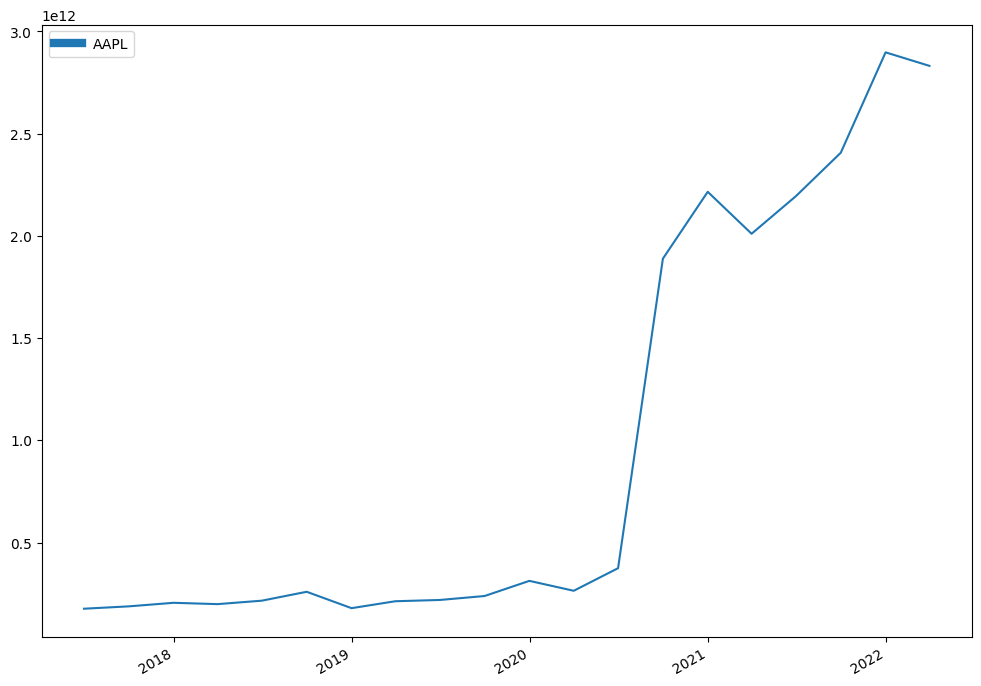

In [9]:
# Test the Plot class
Plot.pretty_plot(AlphaVantage.marketCap(['AAPL']))